# 从 JDX 直接生成 PyTorch .pt（不落盘 H5）

本 Notebook 将 `build_training_data.ipynb`（JDX→向量）与 `convert_h5_to_pt.ipynb`（H5→PT 的输出格式/元数据规则）合并为一步：**直接从 JDX 扫描、处理、并保存为 `.pt` 文件**。

目标：最终得到的 `.pt` 文件在数据结构与内容上与按“两步法”（先生成 H5+NPY，再转换单个 `.pt`）得到的 `.pt` **一致**。

同时：本实现避免一次性 `np.zeros((N, 28080))` 的 20GB+ 内存分配，改为**流式写入到 `numpy.memmap`/分块张量**，最后一次性 `torch.save`。

注意：
- 为确保尽可能一致，本 Notebook **复用你提供的两个 notebook 的核心处理函数与关键参数**。
- `torch.save` 本身会产生 zip 容器格式；要做到"字节一模一样"通常依赖完全一致的 PyTorch 版本与序列化细节。这里我们保证 **保存的数据内容与字典结构一致**；在同一环境/同版本 PyTorch 下应当得到一致的文件内容。

## 1. 参数设置

请按你的数据目录修改以下路径。参数与 `build_training_data.ipynb` 中保持一致。

In [1]:
from pathlib import Path

# ============ 路径配置 ============
HNMR_DIR = Path(r'D:\code\OPCW_data\OPCW_JDX_BY_CLASS_H\1_B_10')
CNMR_DIR = Path(r'D:\code\OPCW_data\OPCW_JDX_BY_CLASS_C\1_B_10')

OUTPUT_DIR = Path(r'D:\code\OPCW_data\1_B_10')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = '1_B_10'

# ============ 处理参数 ============
HNMR_PPM_MIN = -2.0
HNMR_PPM_MAX = 12.0
HNMR_VECTOR_SIZE = 28000

CNMR_PPM_MIN = 0.0
CNMR_PPM_MAX = 230.0
CNMR_VECTOR_SIZE = 80
CNMR_THRESHOLD = 0.05

TOTAL_VECTOR_SIZE = HNMR_VECTOR_SIZE + CNMR_VECTOR_SIZE

# ============ 输出 PT 文件路径 ============
PT_FILE = OUTPUT_DIR / f'{OUTPUT_NAME}.pt'

# ============ 性能/内存配置 ============
# 临时 memmap 用于把大矩阵落盘，避免 RAM 爆掉。
# 如果你中途多次运行/或之前版本用过不同命名规则，目录里可能会残留多个 memmap 临时文件。
# 本 notebook 只使用下面这个文件名。
MEMMAP_FILE = OUTPUT_DIR / f'{OUTPUT_NAME}.spectra.memmap'

# 分批将 memmap 拷贝进 torch.Tensor 的 batch size（只影响峰值内存）
# 如果你内存更紧张，可以把它调小，例如 256/512/1024。
COPY_BATCH_SIZE = 256

# 保存完成后是否自动删除 memmap 临时文件
CLEANUP_MEMMAP_AFTER_SAVE = True

print('参数配置完成!')
print('HNMR_DIR:', HNMR_DIR)
print('CNMR_DIR:', CNMR_DIR)
print('PT_FILE:', PT_FILE)
print('MEMMAP_FILE:', MEMMAP_FILE)
print('TOTAL_VECTOR_SIZE:', TOTAL_VECTOR_SIZE)
print('COPY_BATCH_SIZE:', COPY_BATCH_SIZE)
print('CLEANUP_MEMMAP_AFTER_SAVE:', CLEANUP_MEMMAP_AFTER_SAVE)

参数配置完成!
HNMR_DIR: D:\code\OPCW_data\OPCW_JDX_BY_CLASS_H\1_B_10
CNMR_DIR: D:\code\OPCW_data\OPCW_JDX_BY_CLASS_C\1_B_10
PT_FILE: D:\code\OPCW_data\1_B_10\1_B_10.pt
MEMMAP_FILE: D:\code\OPCW_data\1_B_10\1_B_10.spectra.memmap
TOTAL_VECTOR_SIZE: 28080
COPY_BATCH_SIZE: 256
CLEANUP_MEMMAP_AFTER_SAVE: True


## 2. 导入依赖库

依赖与两个 notebook 一致。

In [2]:
import numpy as np
import torch
from tqdm import tqdm
import urllib.parse
import warnings
warnings.filterwarnings('ignore')

import nmrglue as ng

print('依赖库导入成功')
print('PyTorch:', torch.__version__)
print('CUDA 可用:', torch.cuda.is_available())

依赖库导入成功
PyTorch: 2.5.1
CUDA 可用: True


## 3. 处理函数（与 build_training_data.ipynb 对齐）

In [3]:
def read_jdx_file(file_path: Path):
    """
    读取 JDX，提取原始数据并归一化强度（与 build_training_data.ipynb 一致）。
    """
    dic, raw_data = ng.fileio.jcampdx.read(str(file_path))

    obs_freq = float(dic.get('.OBSERVEFREQUENCY', dic.get('OBSERVEFREQUENCY', [0]))[0])
    first_x = float(dic.get('FIRSTX', [0])[0])
    delta_x = float(dic.get('DELTAX', [0])[0])
    n_points = len(raw_data)

    freq_axis = first_x + np.arange(n_points) * delta_x
    ppm_axis = freq_axis / obs_freq if obs_freq > 0 else freq_axis

    intensity = np.array(raw_data, dtype=np.float64)
    min_intensity = np.min(intensity)
    if min_intensity < 0:
        intensity = intensity - min_intensity

    max_intensity = np.max(intensity)
    if max_intensity > 0:
        intensity = intensity / max_intensity
    else:
        intensity = np.zeros_like(intensity)

    return ppm_axis, intensity


def process_hnmr_spectrum(ppm_axis, intensity,
                          target_ppm_min=HNMR_PPM_MIN,
                          target_ppm_max=HNMR_PPM_MAX,
                          target_size=HNMR_VECTOR_SIZE):
    """将氢谱插值到固定长度，与 build_training_data.ipynb 一致。"""
    target_ppm = np.linspace(target_ppm_min, target_ppm_max, target_size, dtype=np.float64)

    valid_mask = np.isfinite(ppm_axis) & np.isfinite(intensity)
    ppm_clean = ppm_axis[valid_mask]
    intensity_clean = intensity[valid_mask]

    if len(ppm_clean) <= 1:
        return target_ppm.astype(np.float32), np.zeros(target_size, dtype=np.float32)

    order = np.argsort(ppm_clean)
    ppm_sorted = ppm_clean[order]
    intensity_sorted = intensity_clean[order]

    target_intensity = np.interp(
        x=target_ppm,
        xp=ppm_sorted,
        fp=intensity_sorted,
        left=0.0,
        right=0.0
    )

    target_intensity = np.clip(target_intensity, 0.0, None).astype(np.float32)
    return target_ppm.astype(np.float32), target_intensity


def process_cnmr_spectrum(ppm_axis, intensity,
                          ppm_min=CNMR_PPM_MIN,
                          ppm_max=CNMR_PPM_MAX,
                          num_bins=CNMR_VECTOR_SIZE,
                          threshold=CNMR_THRESHOLD):
    """将碳谱处理为二值化 bin 向量，与 build_training_data.ipynb 一致。"""
    bin_edges = np.linspace(ppm_min, ppm_max, num_bins + 1)
    binary_vector = np.zeros(num_bins, dtype=np.float32)

    valid_mask = np.isfinite(ppm_axis) & np.isfinite(intensity)
    ppm_clean = ppm_axis[valid_mask]
    intensity_clean = intensity[valid_mask]

    if len(ppm_clean) == 0:
        return binary_vector

    for i in range(num_bins):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i + 1]
        in_bin_mask = (ppm_clean >= bin_start) & (ppm_clean < bin_end)
        if np.any(in_bin_mask):
            max_intensity_in_bin = np.max(intensity_clean[in_bin_mask])
            if max_intensity_in_bin > threshold:
                binary_vector[i] = 1.0

    return binary_vector

print('处理函数定义完成')

处理函数定义完成


## 4. 扫描并匹配文件（与 build_training_data.ipynb 对齐）

In [4]:
hnmr_files = sorted(list(HNMR_DIR.glob('*.jdx')))
cnmr_files = sorted(list(CNMR_DIR.glob('*.jdx')))
print(f'找到氢谱文件: {len(hnmr_files)} 个')
print(f'找到碳谱文件: {len(cnmr_files)} 个')

hnmr_dict = {}
for f in hnmr_files:
    decoded_name = urllib.parse.unquote(f.stem)
    hnmr_dict[decoded_name] = f

cnmr_dict = {}
for f in cnmr_files:
    decoded_name = urllib.parse.unquote(f.stem)
    cnmr_dict[decoded_name] = f

common_smiles = sorted(set(hnmr_dict.keys()) & set(cnmr_dict.keys()))
hnmr_only = sorted(set(hnmr_dict.keys()) - set(cnmr_dict.keys()))
cnmr_only = sorted(set(cnmr_dict.keys()) - set(hnmr_dict.keys()))
all_smiles = sorted(set(hnmr_dict.keys()) | set(cnmr_dict.keys()))

print(f'同时具有氢谱和碳谱的样本: {len(common_smiles)} 个')
print(f'仅有氢谱的样本: {len(hnmr_only)} 个')
print(f'仅有碳谱的样本: {len(cnmr_only)} 个')
print(f'总样本数: {len(all_smiles)} 个')

if len(all_smiles) == 0:
    raise RuntimeError('没有找到任何谱图文件')

print('示例 SMILES (前5个):')
for smi in all_smiles[:5]:
    has_h = '✓' if smi in hnmr_dict else '✗'
    has_c = '✓' if smi in cnmr_dict else '✗'
    print(f'  [{has_h} H / {has_c} C] {smi}')

找到氢谱文件: 24592 个
找到碳谱文件: 24592 个
同时具有氢谱和碳谱的样本: 24592 个
仅有氢谱的样本: 0 个
仅有碳谱的样本: 0 个
总样本数: 24592 个
示例 SMILES (前5个):
  [✓ H / ✓ C] CC(C(C)(C)C)C(C)(C)COP(C)OCCN(C)C
  [✓ H / ✓ C] CC(C(C)(C)C)C(C)(C)OP(C)OCCN(C)C
  [✓ H / ✓ C] CC(C(C)(C)C)C1(C)CC1OP(C)OCCN(C)C
  [✓ H / ✓ C] CC(C(C)(C)C)C1(COP(C)OCCN(C)C)CC1
  [✓ H / ✓ C] CC(C(C)(C)C)C1(OP(C)OCCN(C)C)CC1


## 5. 流式处理：写入 memmap（解决内存不足）

这里不再 `np.zeros((N, 28080))`，而是创建磁盘上的 `memmap`，逐样本写入。

同时我们保留与原 notebook 一样的：
- 模态缺失用全 0 填充
- 失败样本跳过，并从最终输出剔除（与原 notebook 的逻辑一致）

In [5]:
# 允许覆盖旧文件
if MEMMAP_FILE.exists():
    MEMMAP_FILE.unlink()

num_samples = len(all_smiles)
# memmap shape 先按全量分配；失败的样本稍后通过索引压缩
spectra_mm = np.memmap(str(MEMMAP_FILE), dtype=np.float32, mode='w+', shape=(num_samples, TOTAL_VECTOR_SIZE))

processed_smiles = []
valid_rows = []  # 记录成功写入的行号
failed_smiles = []

hnmr_missing_count = 0
cnmr_missing_count = 0

for idx, smiles in enumerate(tqdm(all_smiles, desc='处理进度')):
    try:
        # H
        if smiles in hnmr_dict:
            hnmr_ppm, hnmr_intensity = read_jdx_file(hnmr_dict[smiles])
            _, hnmr_vector = process_hnmr_spectrum(hnmr_ppm, hnmr_intensity)
        else:
            hnmr_vector = np.zeros(HNMR_VECTOR_SIZE, dtype=np.float32)
            hnmr_missing_count += 1

        # C
        if smiles in cnmr_dict:
            cnmr_ppm, cnmr_intensity = read_jdx_file(cnmr_dict[smiles])
            cnmr_vector = process_cnmr_spectrum(cnmr_ppm, cnmr_intensity)
        else:
            cnmr_vector = np.zeros(CNMR_VECTOR_SIZE, dtype=np.float32)
            cnmr_missing_count += 1

        # 写入 memmap
        spectra_mm[idx, :HNMR_VECTOR_SIZE] = hnmr_vector
        spectra_mm[idx, HNMR_VECTOR_SIZE:] = cnmr_vector

        processed_smiles.append(smiles)
        valid_rows.append(idx)

    except Exception as e:
        failed_smiles.append((smiles, str(e)))

# flush
spectra_mm.flush()

print('处理完成')
print('成功样本数:', len(processed_smiles))
print('失败样本数:', len(failed_smiles))
print('氢谱缺失(全0填充):', hnmr_missing_count)
print('碳谱缺失(全0填充):', cnmr_missing_count)
if failed_smiles:
    print('失败示例(前5):')
    for smi, err in failed_smiles[:5]:
        print('  ', smi[:60], '=>', err[:120])

处理进度: 100%|██████████| 24592/24592 [46:46<00:00,  8.76it/s] 


处理完成
成功样本数: 24592
失败样本数: 0
氢谱缺失(全0填充): 0
碳谱缺失(全0填充): 0


## 6. 构建与两步法一致的 PT 字典并保存

为了与 `convert_h5_to_pt.ipynb` 输出一致，这里保存的字典键保持一致：
- `spectra`: torch.Tensor, shape (N, 28080), dtype float32
- `smiles`: List[str]（从 bytes 解码得到的字符串列表；两步法最终也是 List[str]）
- `metadata`: dict（这里没有 H5，所以我们手动构建与 H5 attrs 等价的字段）
- `num_samples`, `vector_size`, `dtype`, `device`

内存策略：
- 如果 `N x 28080 float32` 仍然放不进内存（例如 N=189255 约 20GB），那两步法在 `convert_h5_to_pt.ipynb` 里同样会在 `torch.empty((N, vector_size))` 失败。
- 但你的目标是生成与两步法一样的 `.pt`，这意味着在你能成功生成两步法 `.pt` 的机器上，这一步也应当可成功。
- 为降低峰值，我们分批从 memmap 拷贝进 CPU Tensor。

In [6]:
# 如果有失败样本，需要压缩 memmap（只保留成功行）
valid_rows = np.array(valid_rows, dtype=np.int64)

# 重新以只读方式打开 memmap
spectra_mm_ro = np.memmap(str(MEMMAP_FILE), dtype=np.float32, mode='r', shape=(num_samples, TOTAL_VECTOR_SIZE))

final_num_samples = len(valid_rows)
vector_size = TOTAL_VECTOR_SIZE

# 构建 metadata：对齐 build_training_data.ipynb 写入 H5 attrs 的字段
metadata = {
    'hnmr_size': HNMR_VECTOR_SIZE,
    'cnmr_size': CNMR_VECTOR_SIZE,
    'total_size': TOTAL_VECTOR_SIZE,
    'hnmr_ppm_min': HNMR_PPM_MIN,
    'hnmr_ppm_max': HNMR_PPM_MAX,
    'cnmr_ppm_min': CNMR_PPM_MIN,
    'cnmr_ppm_max': CNMR_PPM_MAX,
    'cnmr_threshold': CNMR_THRESHOLD,
    'num_samples': final_num_samples,
}

# device/dtype：对齐 convert_h5_to_pt.ipynb 默认（CPU + float32）
device = torch.device('cpu')
target_dtype = torch.float32

print('开始分配 spectra_tensor...')
spectra_tensor = torch.empty((final_num_samples, vector_size), dtype=target_dtype, device=device)

# 关键点：不要用 spectra_mm_ro[rows] 这种“花式索引”
# memmap 在花式索引下会一次性构造一个大的临时 ndarray（例如 4096*28080*4 ~= 439MB），内存紧张时会直接报错。
# 改为：
# 1) 如果本批 rows 在原 memmap 里是连续区间 -> 用切片读取（更省内存 & 更快）
# 2) 否则 -> 逐行拷贝（最省内存，但更慢）

print('开始分批从 memmap 拷贝到 Tensor...')
num_batches = (final_num_samples + COPY_BATCH_SIZE - 1) // COPY_BATCH_SIZE
for b in tqdm(range(num_batches), desc='拷贝批次'):
    s = b * COPY_BATCH_SIZE
    e = min((b + 1) * COPY_BATCH_SIZE, final_num_samples)
    rows = valid_rows[s:e]
    if len(rows) == 0:
        continue
    if (rows[-1] - rows[0] + 1) == len(rows):
        batch_np = spectra_mm_ro[rows[0]:rows[-1] + 1]
        spectra_tensor[s:e] = torch.from_numpy(np.asarray(batch_np))
    else:
        for j, r in enumerate(rows):
            spectra_tensor[s + j] = torch.from_numpy(np.asarray(spectra_mm_ro[r]))

# smiles：对齐 convert_h5_to_pt.ipynb 最终是 List[str]
smiles_list = list(processed_smiles)

data_dict = {
    'spectra': spectra_tensor,
    'smiles': smiles_list,
    'metadata': metadata,
    'num_samples': final_num_samples,
    'vector_size': vector_size,
    'dtype': str(spectra_tensor.dtype),
    'device': str(spectra_tensor.device),
}

print('保存 PT 文件:', PT_FILE)
torch.save(data_dict, PT_FILE)
print('✓ PT 保存完成')
print('  num_samples:', final_num_samples)
print('  spectra:', tuple(spectra_tensor.shape), spectra_tensor.dtype, spectra_tensor.device)
print('  smiles:', len(smiles_list))
print('  metadata keys:', list(metadata.keys()))

# 可选：清理 memmap 临时文件
if CLEANUP_MEMMAP_AFTER_SAVE:
    try:
        import os
        if MEMMAP_FILE.exists():
            os.remove(MEMMAP_FILE)
            print('已删除 memmap 临时文件:', MEMMAP_FILE)
    except Exception as e:
        print('⚠ 清理 memmap 失败（可忽略）:', e)

开始分配 spectra_tensor...
开始分批从 memmap 拷贝到 Tensor...


拷贝批次: 100%|██████████| 97/97 [00:00<00:00, 109.54it/s]


保存 PT 文件: D:\code\OPCW_data\1_B_10\1_B_10.pt
✓ PT 保存完成
  num_samples: 24592
  spectra: (24592, 28080) torch.float32 cpu
  smiles: 24592
  metadata keys: ['hnmr_size', 'cnmr_size', 'total_size', 'hnmr_ppm_min', 'hnmr_ppm_max', 'cnmr_ppm_min', 'cnmr_ppm_max', 'cnmr_threshold', 'num_samples']
⚠ 清理 memmap 失败（可忽略）: [WinError 32] 另一个程序正在使用此文件，进程无法访问。: 'D:\\code\\OPCW_data\\1_B_10\\1_B_10.spectra.memmap'


## 7. 校验（结构/抽样一致性）

这里将加载刚保存的 `.pt`，做字段与形状检查，并抽样检查数值范围。

如果你已经有两步法生成的 `.pt`（同环境下），你可以进一步对比：
- `spectra` 的数值是否完全相同
- `smiles` 列表是否完全相同
- `metadata` 是否一致

抽查样本索引: 14093
SMILES: CCCC1CCCCC(OP(C)OCCN(C)C)C1
是否有氢谱文件: ✓ D:\code\OPCW_data\OPCW_JDX_BY_CLASS_H\1_B_10\CCCC1CCCCC(OP(C)OCCN(C)C)C1.jdx
是否有碳谱文件: ✓ D:\code\OPCW_data\OPCW_JDX_BY_CLASS_C\1_B_10\CCCC1CCCCC(OP(C)OCCN(C)C)C1.jdx


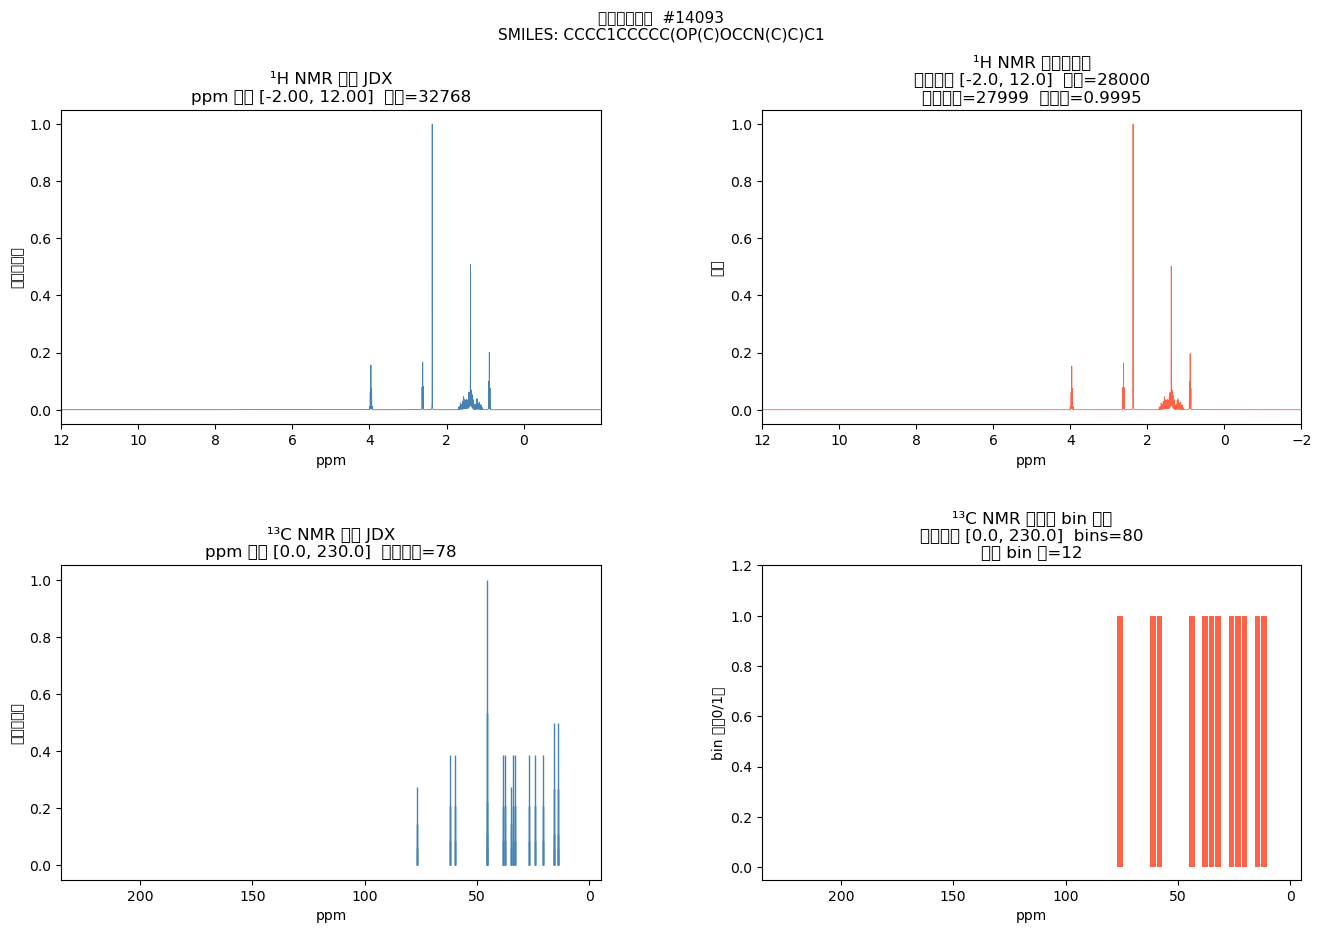


请手动打开以下文件核对:
  氢谱 JDX: D:\code\OPCW_data\OPCW_JDX_BY_CLASS_H\1_B_10\CCCC1CCCCC(OP(C)OCCN(C)C)C1.jdx
  碳谱 JDX: D:\code\OPCW_data\OPCW_JDX_BY_CLASS_C\1_B_10\CCCC1CCCCC(OP(C)OCCN(C)C)C1.jdx


In [7]:

import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ============ 随机抽取一个样本 ============
# 可手动指定 SAMPLE_IDX，或设为 None 让其随机选取
SAMPLE_IDX = None

rng = random.Random()
if SAMPLE_IDX is None:
    SAMPLE_IDX = rng.randint(0, len(processed_smiles) - 1)

sample_smiles = processed_smiles[SAMPLE_IDX]
print(f'抽查样本索引: {SAMPLE_IDX}')
print(f'SMILES: {sample_smiles}')
print(f'是否有氢谱文件: {"✓ " + str(hnmr_dict[sample_smiles]) if sample_smiles in hnmr_dict else "✗ 无（全零填充）"}')
print(f'是否有碳谱文件: {"✓ " + str(cnmr_dict[sample_smiles]) if sample_smiles in cnmr_dict else "✗ 无（全零填充）"}')

# ============ 从 spectra_tensor 取出该样本的向量 ============
vec = spectra_tensor[SAMPLE_IDX].numpy()
hnmr_vec = vec[:HNMR_VECTOR_SIZE]
cnmr_vec = vec[HNMR_VECTOR_SIZE:]

hnmr_ppm_axis = np.linspace(HNMR_PPM_MIN, HNMR_PPM_MAX, HNMR_VECTOR_SIZE)
cnmr_bin_centers = np.linspace(CNMR_PPM_MIN, CNMR_PPM_MAX, CNMR_VECTOR_SIZE)

# ============ 同时重新读取原始 JDX，用于对比 ============
orig_hnmr_ppm = orig_hnmr_intensity = None
orig_cnmr_ppm = orig_cnmr_intensity = None

if sample_smiles in hnmr_dict:
    orig_hnmr_ppm, orig_hnmr_intensity = read_jdx_file(hnmr_dict[sample_smiles])
if sample_smiles in cnmr_dict:
    orig_cnmr_ppm, orig_cnmr_intensity = read_jdx_file(cnmr_dict[sample_smiles])

# ============ 绘图 ============
fig = plt.figure(figsize=(16, 10))
fig.suptitle(f'随机抽查样本  #{SAMPLE_IDX}\nSMILES: {sample_smiles[:80]}', fontsize=11)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# --- 氢谱：原始 JDX ---
ax0 = fig.add_subplot(gs[0, 0])
if orig_hnmr_ppm is not None:
    ax0.plot(orig_hnmr_ppm, orig_hnmr_intensity, lw=0.6, color='steelblue')
    ax0.set_xlim(orig_hnmr_ppm.min(), orig_hnmr_ppm.max())
    ax0.set_title(f'¹H NMR 原始 JDX\nppm 范围 [{orig_hnmr_ppm.min():.2f}, {orig_hnmr_ppm.max():.2f}]  点数={len(orig_hnmr_ppm)}')
else:
    ax0.text(0.5, 0.5, '无氢谱文件（全零填充）', ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title('¹H NMR 原始 JDX')
ax0.set_xlabel('ppm')
ax0.set_ylabel('归一化强度')
ax0.invert_xaxis()

# --- 氢谱：处理后向量 ---
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(hnmr_ppm_axis, hnmr_vec, lw=0.6, color='tomato')
ax1.set_xlim(HNMR_PPM_MIN, HNMR_PPM_MAX)
ax1.set_title(f'¹H NMR 处理后向量\n目标范围 [{HNMR_PPM_MIN}, {HNMR_PPM_MAX}]  点数={HNMR_VECTOR_SIZE}\n'
              f'非零点数={int((hnmr_vec > 0).sum())}  最大值={hnmr_vec.max():.4f}')
ax1.set_xlabel('ppm')
ax1.set_ylabel('强度')
ax1.invert_xaxis()

# --- 碳谱：原始 JDX（峰位散点） ---
ax2 = fig.add_subplot(gs[1, 0])
if orig_cnmr_ppm is not None:
    # 只画超过阈值的峰，模拟谱线
    mask = orig_cnmr_intensity > CNMR_THRESHOLD
    ax2.vlines(orig_cnmr_ppm[mask], 0, orig_cnmr_intensity[mask], lw=1.0, color='steelblue')
    ax2.set_xlim(orig_cnmr_ppm.min() - 5, orig_cnmr_ppm.max() + 5)
    ax2.set_title(f'¹³C NMR 原始 JDX\nppm 范围 [{orig_cnmr_ppm.min():.1f}, {orig_cnmr_ppm.max():.1f}]  '
                  f'有效峰数={int(mask.sum())}')
else:
    ax2.text(0.5, 0.5, '无碳谱文件（全零填充）', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('¹³C NMR 原始 JDX')
ax2.set_xlabel('ppm')
ax2.set_ylabel('归一化强度')
ax2.invert_xaxis()

# --- 碳谱：处理后 bin 向量 ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(cnmr_bin_centers, cnmr_vec,
        width=(CNMR_PPM_MAX - CNMR_PPM_MIN) / CNMR_VECTOR_SIZE * 0.85,
        color='tomato', align='center')
ax3.set_xlim(CNMR_PPM_MIN - 5, CNMR_PPM_MAX + 5)
ax3.set_ylim(-0.05, 1.2)
ax3.set_title(f'¹³C NMR 处理后 bin 向量\n目标范围 [{CNMR_PPM_MIN}, {CNMR_PPM_MAX}]  bins={CNMR_VECTOR_SIZE}\n'
              f'激活 bin 数={int(cnmr_vec.sum())}')
ax3.set_xlabel('ppm')
ax3.set_ylabel('bin 值（0/1）')
ax3.invert_xaxis()

plt.show()
print(f'\n请手动打开以下文件核对:')
if sample_smiles in hnmr_dict:
    print(f'  氢谱 JDX: {hnmr_dict[sample_smiles]}')
if sample_smiles in cnmr_dict:
    print(f'  碳谱 JDX: {cnmr_dict[sample_smiles]}')
